In [1]:
'''
This code compares the obstacle-free solver with the analytic solution for advection-diffusion of a Gaussian puff in 2d.
As it turns out, the analytic solution for a Gaussian puff is always Gaussian.
'''

gpu = True # make sure this matches other 4 files
if gpu:
    import cupy as np
else:
    import numpy as np
from simulate import simulate
from matplotlib import pyplot as plt

using gpu
using gpu
using gpu


In [2]:
## parameters ##
# grid setup
dx = 0.2 + 2/30
Lx = 24
Lz = 12
stop_time = .3
nsteps_per_second = 40*1/.3
D = 1
gamma = 1/2
c = 1/8

# initial conditions for C
# xs = 12
# zs = 4
# initial_sigma = 0.5
source_location = np.array([12,4])
source_spread = 0.5
source_type = 'puff'
n_copies = 10

# obstacle parameters
obstacle = False
shape_params = np.array([16,4,1]) # should be centerx,centerz, radius for circle

# wind MFS parameters
uinf = 10
rs_wind = 0.2
rs_wind_int = 1.2
Ns_wind = 100
Nb_wind = 120

# concentration MFS parameters
rs_conc = 0.8
cutoff = 35
rs_conc_int = 1 - 2*dx
Nb_conc = 60
Ns_conc = 50
# Nb_conc_int = 60 # currently just using Nb_conc for this number
Ns_conc_int = 20
sigma = 0.9*dx

h = simulate(
    gpu,
    dx,
    Lx,
    Lz,
    stop_time,
    nsteps_per_second,
    D,
    gamma,
    c,

    # initial conditions for C
    # xs,
    # zs,
    # initial_sigma,
    n_copies,

    # obstacle parameters
    obstacle,
    shape_params,

    # wind MFS parameters
    uinf,
    rs_wind,
    rs_wind_int,
    Ns_wind,
    Nb_wind,

    # concentration MFS parameters
    rs_conc,
    cutoff,
    rs_conc_int,
    Nb_conc,
    Ns_conc,
    Ns_conc_int,
    sigma,
    )

c:\Users\sedox\miniconda3\Lib\site-packages\cupyx\scipy\sparse\_compressed.py:760: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive.
  warnings.warn('Changing the sparsity structure of a '


In [3]:
## get analytic solution at stop_time ##
pi = np.pi
norm = np.linalg.norm
Dt0 = (source_spread)**2/2
def c_star(x,z,t,xs,zs,u,Dt0):
    # these functions are specifically for 2 dimensions
    return (1/(2*pi*2*(t+Dt0)))*np.exp( -((x - xs - u*t)**2 + (z - zs)**2)/(4*(t + Dt0)) )

def puff_analytic(x, z, t, source_location, u, Dt0):
    xs = source_location[0]
    zs = source_location[1]
    return c_star(x,z,t,xs,zs,u,Dt0) + c_star(x,-z,t,xs,zs,u,Dt0)

C_analytic = np.zeros((h.Nz, h.Nx))
for copy_idx in np.arange(-n_copies,n_copies+1):
    C_analytic = C_analytic + puff_analytic(h.X-copy_idx*Lx, h.Z, stop_time, source_location, uinf, Dt0)

In [4]:
## compare for various timestep sizes, make sure convergence is quadratic. ##
nsteps_per_second_array = np.array([40,80,120,160])/stop_time
error_vec = np.zeros(len(nsteps_per_second_array))
dt_vec = np.zeros(len(nsteps_per_second_array))
for i,nsteps_per_second in enumerate(nsteps_per_second_array):
    h = simulate(
    gpu,
    dx,
    Lx,
    Lz,
    stop_time,
    nsteps_per_second,
    D,
    gamma,
    c,

    # initial conditions for C
    # xs,
    # zs,
    # initial_sigma,
    n_copies,

    # obstacle parameters
    obstacle,
    shape_params,

    # wind MFS parameters
    uinf,
    rs_wind,
    rs_wind_int,
    Ns_wind,
    Nb_wind,

    # concentration MFS parameters
    rs_conc,
    cutoff,
    rs_conc_int,
    Nb_conc,
    Ns_conc,
    Ns_conc_int,
    sigma,
    )
    h.run(source_location, source_spread, source_type)
    err = norm(h.C - C_analytic)/norm(C_analytic)
    error_vec[i] = err
    dt_vec[i] = h.dt

print(error_vec)

starting sim ...
end of sim
starting sim ...
end of sim
starting sim ...
end of sim
starting sim ...
end of sim
[0.01276889 0.00312878 0.00138426 0.00077714]


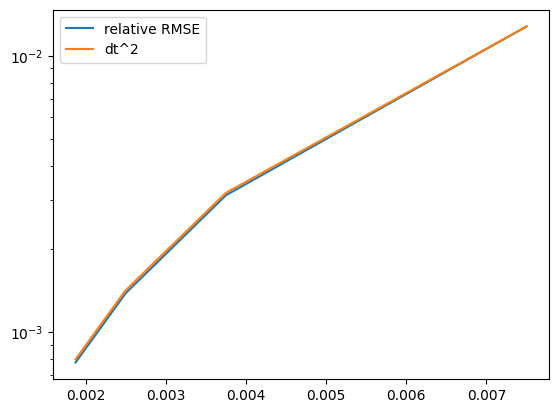

In [5]:
## plot the error as a function of dt. Should be order dt^2 **
if gpu:
    error_vec = error_vec.get()
    dt_vec = dt_vec.get()
plt.plot(dt_vec,error_vec,label='relative RMSE')
plt.plot(dt_vec,(error_vec[0]/dt_vec[0]**2) * dt_vec**2,label='dt^2')
plt.yscale('log')
plt.legend()

In [6]:
## verify that error has quadratic convergence ##
relative_vec = (error_vec[0]/dt_vec[0]**2) * dt_vec**2
# print(np.max(np.abs(relative_vec-error_vec)))
# print(np.max(np.abs(relative_vec-error_vec)) / np.max(relative_vec))
pass_flag = np.allclose(relative_vec, error_vec, rtol = 0.01, atol = 1e-04)
if pass_flag:
    print('Test passed.')
else:
    print('Test failed: ')
    print(f'absolute error {np.max(np.abs(relative_vec-error_vec))}')
    print(f'relative error: {np.max(np.abs(relative_vec-error_vec)) / np.max(relative_vec)}')

Test passed.
